Некст левел плей датасет с персонажами из доты. Я выбрал категоризацию персонажа по голосу. всего взято 5 персов, но у каждого по 300 дорожек, так что думаю норм. Датасет находится в Google Drive, поэтому вот такой код для выгрузки(я хз как будет работать конкретно в юпитере я использую гугл коллаб)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = '/content/drive/MyDrive/AudioDataSet'

import os
for char in os.listdir(dataset_path):
    char_path = os.path.join(dataset_path, char)
    if os.path.isdir(char_path):
        files = len([f for f in os.listdir(char_path) if f.endswith('.mp3')])
        print(f"{char}: {files} файлов")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Crystal_Maiden: 369 файлов
Invoker: 354 файлов
Silencer: 296 файлов
Templar_Assassin: 303 файлов
Winter_Wyvern: 346 файлов


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import librosa
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

config = {
    'sample_rate': 22050,
    'duration': 3.0,
    'n_mels': 128,
    'n_fft': 2048,
    'hop_length': 512,
    'batch_size': 40,
    'epochs': 30,
    'learning_rate': 0.005,
    'weight_decay': 0,
    'hidden_size': 60,
    'num_layers': 4,
    'dropout': 0.3,
    'cache_dir': '/content/data_processed'
}

Path(config['cache_dir']).mkdir(exist_ok=True)


Lstm ячейки должно быть достаточно, поэтому реализую её

In [3]:
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        self.weight_ih = nn.Parameter(torch.randn(4 * hidden_size, input_size) / (input_size ** 0.5))
        self.weight_hh = nn.Parameter(torch.randn(4 * hidden_size, hidden_size) / (hidden_size ** 0.5))
        self.bias = nn.Parameter(torch.zeros(4 * hidden_size))

    def forward(self, x, state):
        hidden_state, cell_state = state
        gates = torch.mm(x, self.weight_ih.t()) + torch.mm(hidden_state, self.weight_hh.t()) + self.bias
        input_gate, forget_gate, candidate_gate, output_gate = gates.chunk(4, 1)

        candidate_gate = torch.tanh(candidate_gate)
        output_gate = torch.sigmoid(output_gate)
        forget_gate = torch.sigmoid(forget_gate)
        input_gate = torch.sigmoid(input_gate)

        C_new = forget_gate * cell_state + input_gate * candidate_gate
        h_new = output_gate * torch.tanh(C_new)

        return h_new, C_new

class LSTMLayer(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, batch_first=False, dropout=0.0):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.batch_first = batch_first

        self.cells = nn.ModuleList([LSTMCell(input_size if i == 0 else hidden_size, hidden_size) for i in range(num_layers)])

        if dropout > 0 and num_layers > 1:
            self.dropout_layer = nn.Dropout(dropout)
        else:
            self.dropout_layer = None

    def forward(self, x, state=None):
        if self.batch_first:
            x = x.transpose(0, 1)

        seq_len, batch_size, _ = x.size()

        if state is None:
            hidden_state = [torch.zeros(batch_size, self.hidden_size, dtype=x.dtype, device=x.device) for _ in range(self.num_layers)]
            cell_state = [torch.zeros(batch_size, self.hidden_size, dtype=x.dtype, device=x.device) for _ in range(self.num_layers)]
        else:
            hidden_state, cell_state = state

        output = []

        for t in range(seq_len):
            x_t = x[t]

            for layer_idx in range(self.num_layers):
                hidden_state[layer_idx], cell_state[layer_idx] = self.cells[layer_idx](x_t, (hidden_state[layer_idx], cell_state[layer_idx]))
                x_t = hidden_state[layer_idx]

                if self.dropout_layer is not None and layer_idx < self.num_layers - 1:
                    x_t = self.dropout_layer(x_t)

            output.append(hidden_state[-1])

        output = torch.stack(output, dim=0)
        if self.batch_first:
            output = output.transpose(0, 1)

        return output, (hidden_state, cell_state)


class DotaVoiceClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, num_layers=2, dropout=0.3):
        super().__init__()

        self.lstm = LSTMLayer(input_size=input_size, hidden_size=hidden_size,
                             num_layers=num_layers, batch_first=True,
                             dropout=dropout)

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes))

    def forward(self, x):
        output, (h, C) = self.lstm(x)
        embeddings = h[-1]
        logits = self.fc(embeddings)
        return logits, embeddings

Надо предобработать аудио, чтобы получить эмбединги. Для этого получим мел-спектрограмму для каждого войслайна(да да как в теории по лабе ура)


In [4]:
class DotaVoiceDataset(Dataset):
    def __init__(self, audio_paths, labels, config, use_cache=True):
        self.audio_paths = audio_paths
        self.labels = labels
        self.config = config
        self.use_cache = use_cache

        self.cache_dir = Path(config['cache_dir'])
        self.cache_dir.mkdir(exist_ok=True)

    def _get_cache_path(self, audio_path):
        return self.cache_dir / (Path(audio_path).stem + '.npy')

    def _preprocess_audio(self, audio_path):
        y, sr = librosa.load(
            audio_path,
            sr=self.config['sample_rate'],
            duration=3.0)

        target_length = int(self.config['sample_rate'] * 3.0)
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)), mode='wrap')
        else:
            y = y[:target_length]

        mel_spec = librosa.feature.melspectrogram(
            y=y,
            sr=self.config['sample_rate'],
            n_mels=self.config['n_mels'],
            n_fft=self.config['n_fft'],
            hop_length=self.config['hop_length']
        )

        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        mel_spec_db = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-9)

        return mel_spec_db.T

    def _preprocess_and_cache(self):
        print("Предобработка...")
        for audio_path in tqdm(self.audio_paths):
            cache_path = self._get_cache_path(audio_path)
            if cache_path.exists():
                continue
            mel_spec = self._preprocess_audio(audio_path)
            np.save(cache_path, mel_spec)

    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):
        audio_path = self.audio_paths[idx]
        label = self.labels[idx]
        mel_spec_db = self._preprocess_audio(audio_path)

        return torch.FloatTensor(mel_spec_db), torch.tensor(label, dtype=torch.long)

Применим код, что был выше и поделим данные на тестовую валидационную и тренировычные части

In [5]:
dataset_path = Path(dataset_path)
char_folders = sorted([f for f in dataset_path.iterdir() if f.is_dir()])
character_names = [f.name for f in char_folders]

print(f"Персонажи: {character_names}\n")

char_to_idx = {name: idx for idx, name in enumerate(character_names)}

audio_paths = []
labels = []

for char_folder in char_folders:
    audio_files = list(char_folder.glob('*.mp3'))
    print(f"{char_folder.name}: {len(audio_files)} файлов")
    for audio_file in audio_files:
        audio_paths.append(str(audio_file))
        labels.append(char_to_idx[char_folder.name])

print(f"\n Всего: {len(audio_paths)} файлов")


train_paths, test_paths, train_labels, test_labels = train_test_split(
    audio_paths, labels, test_size=0.2, stratify=labels, random_state=42
)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels, test_size=0.125, stratify=train_labels, random_state=42
)

print(f"\n Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")

train_dataset = DotaVoiceDataset(train_paths, train_labels, config)
val_dataset = DotaVoiceDataset(val_paths, val_labels, config)
test_dataset = DotaVoiceDataset(test_paths, test_labels, config)

train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)

print("Данные готовы")

Персонажи: ['Crystal_Maiden', 'Invoker', 'Silencer', 'Templar_Assassin', 'Winter_Wyvern']

Crystal_Maiden: 369 файлов
Invoker: 354 файлов
Silencer: 296 файлов
Templar_Assassin: 303 файлов
Winter_Wyvern: 346 файлов

 Всего: 1668 файлов

 Train: 1167, Val: 167, Test: 334
Данные готовы


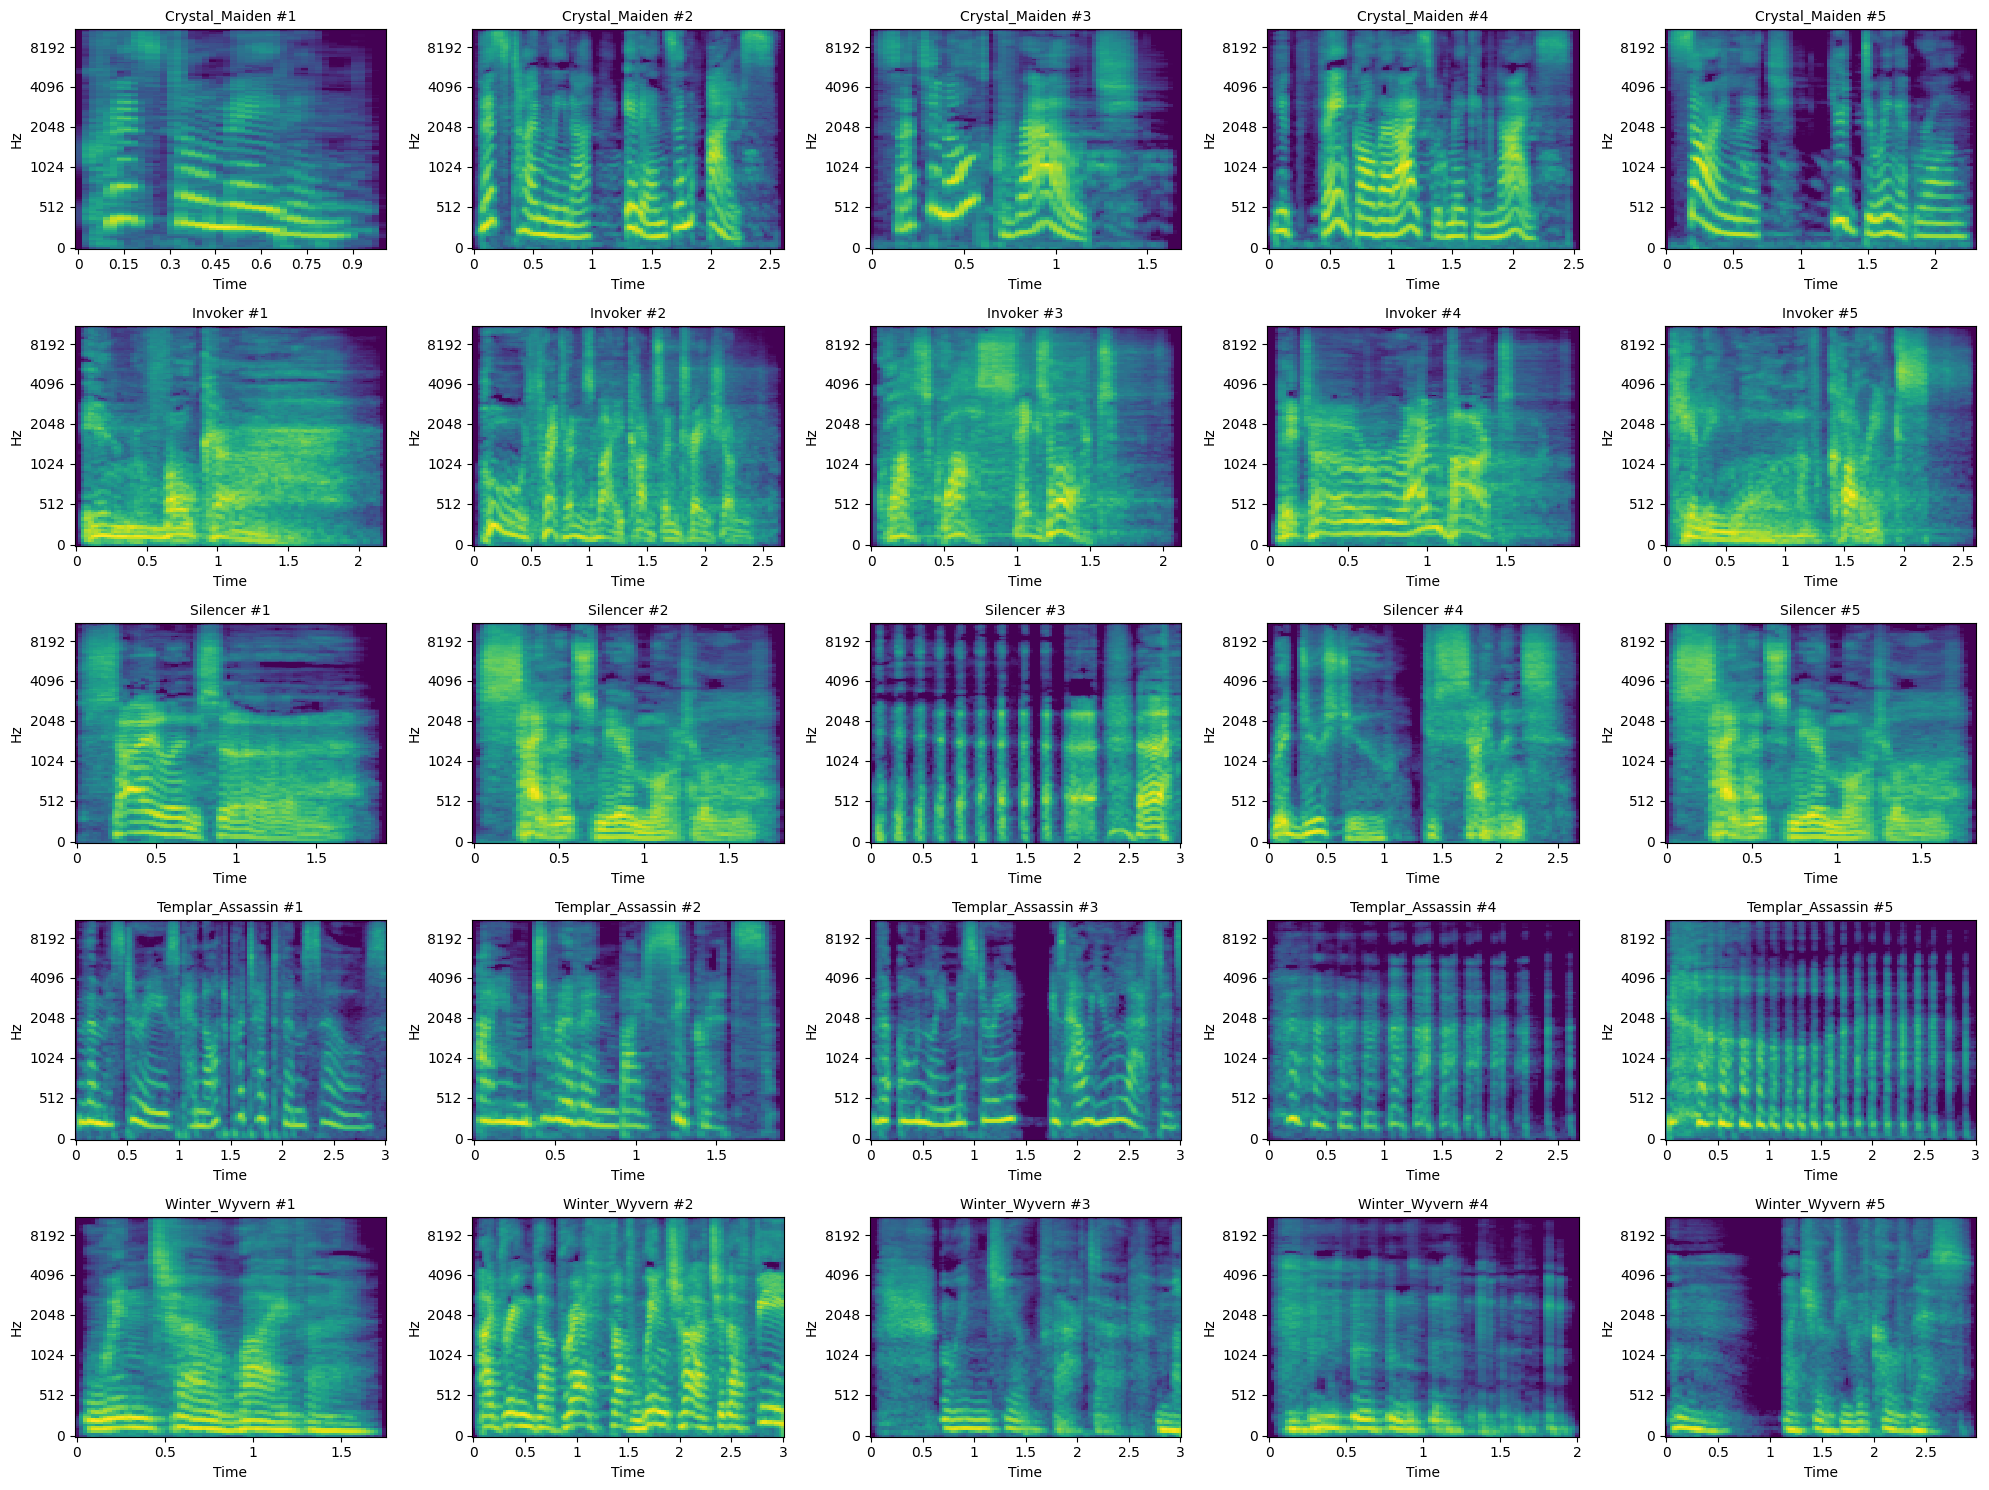

In [6]:
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

sample_rate = config['sample_rate']
n_mels = config['n_mels']
n_fft = config['n_fft']
hop_length = config['hop_length']


fig, axes = plt.subplots(len(character_names), 5, figsize=(20, 15))

for char_idx, char_name in enumerate(character_names):
    char_path = f'{dataset_path}/{char_name}'
    import os
    files = sorted([f for f in os.listdir(char_path) if f.endswith('.mp3')])


    for i in range(5):
        if i < len(files):
            audio_path = f'{char_path}/{files[i]}'

            try:
                y, sr = librosa.load(audio_path, sr=sample_rate, duration=3.0)

                mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
                mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

                ax = axes[char_idx, i]
                img = librosa.display.specshow(
                    mel_spec_db, sr=sr, hop_length=hop_length,
                    x_axis='time', y_axis='mel', ax=ax, cmap='viridis')

                ax.set_title(f'{char_name} #{i+1}', fontsize=10)

            except Exception as e:
                ax = axes[char_idx, i]
                ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center')
                ax.set_title(f'{char_name} #{i+1}', fontsize=10)

plt.tight_layout()
plt.savefig('spectrograms_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Красота.
Судя по всему лучший персонаж доты(темпларочка) смеётся в 4 и 5 войслайне. незабываемая штука особенно мейнерам та. хе-хе

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используем: {device}\n")

model = DotaVoiceClassifier(
    input_size=config['n_mels'],
    hidden_size=config['hidden_size'],
    num_classes=len(character_names),
    num_layers=config['num_layers'],
    dropout=config['dropout']
).to(device)

print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}\n")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

Используем: cpu

Параметров: 140,933



In [8]:
def train_epoch(model, train_loader, optimizer, loss_fn, device):
    model.train()

    epoch_loss = 0
    correct_predictions = 0
    total_samples = 0

    for batch_specs, batch_labels in tqdm(train_loader, desc="Обучение"):
        batch_specs = batch_specs.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        predictions, _ = model(batch_specs)
        loss = loss_fn(predictions, batch_labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        _, predicted_classes = torch.max(predictions, dim=1)

        correct_predictions += (predicted_classes == batch_labels).sum().item()
        total_samples += batch_labels.size(0)

    avg_loss = epoch_loss / len(train_loader)
    accuracy = correct_predictions / total_samples

    return avg_loss, accuracy


def validate(model, val_loader, loss_fn, device):
    model.eval()

    val_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for batch_specs, batch_labels in tqdm(val_loader, desc="Валидация"):
            batch_specs = batch_specs.to(device)
            batch_labels = batch_labels.to(device)

            predictions, _ = model(batch_specs)

            loss = loss_fn(predictions, batch_labels)

            val_loss += loss.item()

            _, predicted_classes = torch.max(predictions, dim=1)

            correct_predictions += (predicted_classes == batch_labels).sum().item()
            total_samples += batch_labels.size(0)

    avg_loss = val_loss / len(val_loader)
    accuracy = correct_predictions / total_samples

    return avg_loss, accuracy


In [9]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')

for epoch in range(1, config['epochs'] + 1):
    print(f"Эпоха {epoch}/{config['epochs']}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train: loss={train_loss:.4f}, acc={train_acc:.4f}")
    print(f"Val:   loss={val_loss:.4f}, acc={val_acc:.4f}\n")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print("Лучшая модель сохранена!\n")

print("Обучение завершено")

Эпоха 1/30


Валидация: 100%|██████████| 5/5 [00:03<00:00,  1.63it/s]


Train: loss=1.2567, acc=0.4576
Val:   loss=1.4393, acc=0.4850

Лучшая модель сохранена!

Эпоха 2/30


Валидация: 100%|██████████| 5/5 [00:03<00:00,  1.31it/s]


Train: loss=1.2863, acc=0.4156
Val:   loss=1.2819, acc=0.4072

Лучшая модель сохранена!

Эпоха 3/30


...

Train: loss=0.3297, acc=0.9015
Val:   loss=0.3645, acc=0.8683

Эпоха 29/30


Валидация: 100%|██████████| 5/5 [00:04<00:00,  1.24it/s]


Train: loss=0.3162, acc=0.8972
Val:   loss=0.3404, acc=0.9042

Лучшая модель сохранена!

Эпоха 30/30


Валидация: 100%|██████████| 5/5 [00:03<00:00,  1.37it/s]

Train: loss=0.2898, acc=0.9049
Val:   loss=0.2683, acc=0.9341

Лучшая модель сохранена!

Обучение завершено


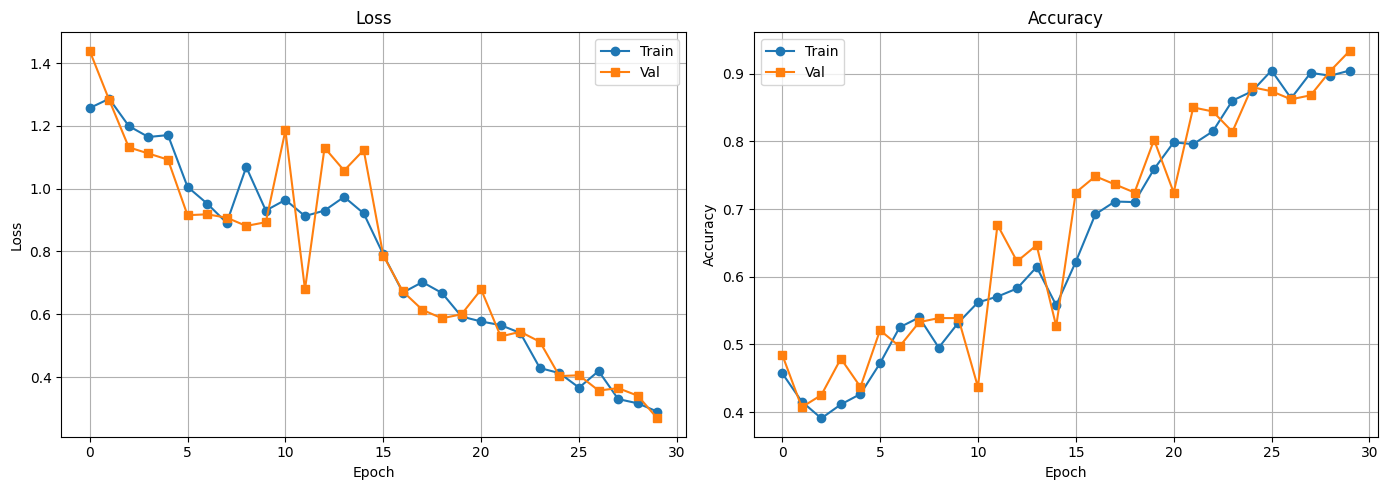

train_loss
[1.2566779255867004, 1.2862563729286194, 1.1993586818377178, 1.1644408106803894, 1.170509539047877, 1.0055635631084443, 0.9524788856506348, 0.8910563468933106, 1.0687649289766947, 0.9302151083946228, 0.9641737759113311, 0.9125844021638234, 0.9302020688851674, 0.973657218615214, 0.9210407932599386, 0.7902248938878377, 0.6689543465773264, 0.7021927187840143, 0.6674993286530176, 0.5924900293350219, 0.5769322981437047, 0.5651289194822311, 0.5402869140108426, 0.4284932499130567, 0.4124136423071226, 0.3661577314138412, 0.4189983166754246, 0.32969669848680494, 0.31616051147381463, 0.28976036806901295]
val_loss
[1.4392698764801026, 1.281923532485962, 1.1315021514892578, 1.1119322299957275, 1.092383587360382, 0.9153181791305542, 0.9182156801223755, 0.9074603915214539, 0.8811722278594971, 0.8930721402168273, 1.18537380695343, 0.6789310991764068, 1.1302469491958618, 1.0575596928596496, 1.1229678511619567, 0.7869190812110901, 0.6723754644393921, 0.6138431668281555, 0.5868971407413482, 0

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'], label='Val', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train', marker='o')
axes[1].plot(history['val_acc'], label='Val', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

print("train_loss")
print(history['train_loss'])

print("val_loss")
print(history['val_loss'])

In [11]:
model.load_state_dict(torch.load('best_model.pth'))
test_loss, test_acc = validate(model, test_loader, criterion, device)


print("РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Валидация: 100%|██████████| 9/9 [00:05<00:00,  1.59it/s]

РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ
Test Loss: 0.2285
Test Accuracy: 0.9281


Кайф, модель хорошо обучена, осталось только вытащить эмбединги

Размер эмбеддингов: (334, 60)
Размер меток: (334,)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 334 samples in 0.001s...
[t-SNE] Computed neighbors for 334 samples in 0.037s...
[t-SNE] Computed conditional probabilities for sample 334 / 334
[t-SNE] Mean sigma: 0.100629


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] KL divergence after 250 iterations with early exaggeration: 40.234879
[t-SNE] KL divergence after 1000 iterations: 0.092585
t-SNE результат: (334, 2)


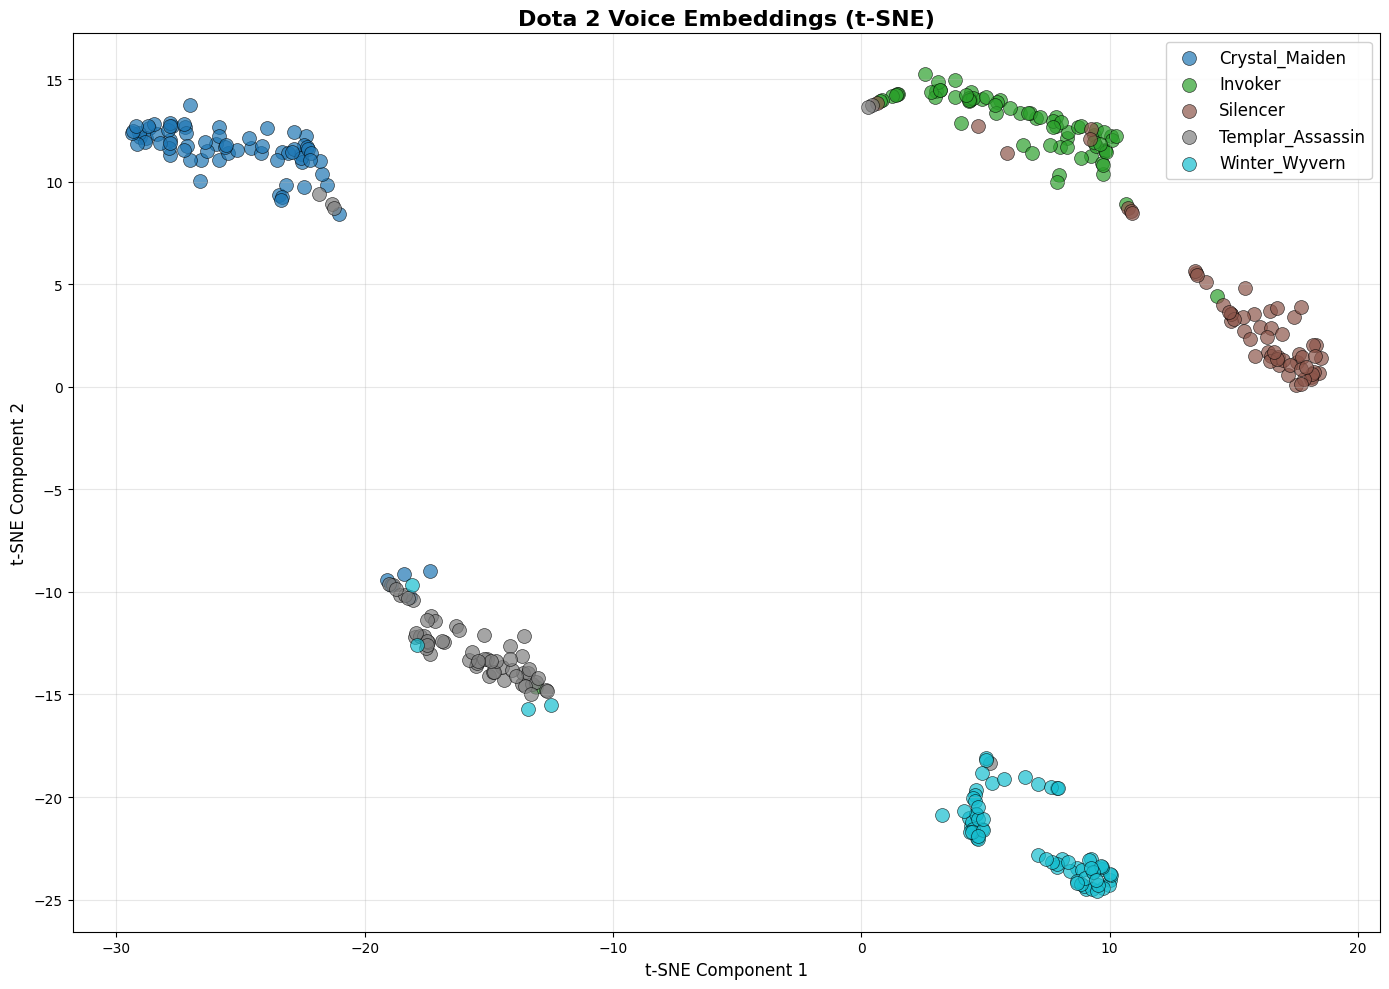

Центроидов по классам:
 Crystal_Maiden      : центр=( -25.07,   10.20), разброс=4.21
 Invoker             : центр=(   6.26,   12.40), разброс=3.68
 Silencer            : центр=(  15.37,    3.47), разброс=3.46
 Templar_Assassin    : центр=( -15.10,  -10.94), разброс=5.60
 Winter_Wyvern       : центр=(   5.76,  -21.60), разброс=4.25


In [12]:
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

model.eval()
all_embeddings = []
all_labels = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        _, embeddings = model(x_batch)
        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.extend(y_batch.numpy())

embeddings = np.concatenate(all_embeddings, axis=0)
labels = np.array(all_labels)

print(f"Размер эмбеддингов: {embeddings.shape}")
print(f"Размер меток: {labels.shape}")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=1)
embeddings_2d = tsne.fit_transform(embeddings)

print(f"t-SNE результат: {embeddings_2d.shape}")

plt.figure(figsize=(14, 10))

colors = plt.cm.tab10(np.linspace(0, 1, len(character_names)))

for i, char_name in enumerate(character_names):
    mask = labels == i
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=char_name,
        s=100,
        alpha=0.7,
        color=colors[i],
        edgecolors='black',
        linewidth=0.5
    )

plt.legend(fontsize=12, loc='best', framealpha=0.9)
plt.title('Dota 2 Voice Embeddings (t-SNE)', fontsize=16, fontweight='bold')
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()


plt.savefig('embeddings_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Центроидов по классам:")

for i, char_name in enumerate(character_names):
    mask = labels == i
    cluster_embeddings = embeddings_2d[mask]
    centroid = cluster_embeddings.mean(axis=0)
    dispersion = cluster_embeddings.std(axis=0).mean()

    print(f" {char_name:20s}: центр=({centroid[0]:7.2f}, {centroid[1]:7.2f}), разброс={dispersion:.2f}")

Как можно увидеть построение эмбеддингов из последнего слоя LSTM и их визуализация в 2D с помощью t-SNE показала разумную группировку по персонажам, что подтверждает, что модель формирует осмысленное признаковое пространство для голосов и действительно извлекает устойчивые отличительные признаки из аудио.